<a href="https://colab.research.google.com/github/Lucianadeoliveira/gaTE-lab/blob/main/FRALCAT/codePyMol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installing PyMOL

This code block installs **PyMOL**, the molecular visualization tool required for generating 3D images of predicted structures.

```bash
!apt-get update
!apt-get install -y pymol


### Mounting Google Drive

This code mounts your Google Drive to the Colab environment, allowing the notebook to access files stored in your Drive.

```python
from google.colab import drive
drive.mount('/content/drive')


Processing /content/drive/MyDrive/GateLab-ProjetoTT5- Marie Anne/backup dados AlphaFold remontagem/contigs/3-suscetiveis/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162.result/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb
/bin/bash: line 1: pymol: command not found
Saved image to /content/drive/MyDrive/GateLab-ProjetoTT5- Marie Anne/backup dados AlphaFold remontagem/contigs/3-suscetiveis/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162.result/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.png


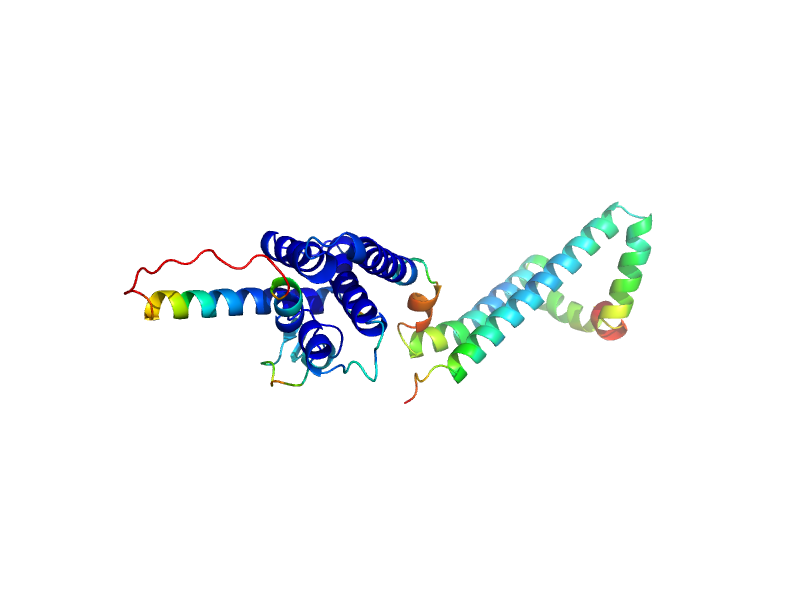

PDB structures processed and images saved.


In [ ]:
import os
from IPython.display import Image, display

# Directory containing PDB files
base_dir = '/content/drive/MyDrive/GateLab-ProjetoTT5- Marie Anne/backup dados AlphaFold remontagem/contigs/3-suscetiveis/CB49_13_14_15_TRINITY_DN1057_c1_g2_i1_0_2d162.result'

# Collect all PDB file paths recursively that contain 'rank_001' in their filename
file_paths = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".pdb") and "rank_001" in file:  # Only add .pdb files with 'rank_001'
            file_paths.append(os.path.join(root, file))

# Loop through the file paths and generate/execute PyMOL scripts
for file_path in file_paths:
    print(f"Processing {file_path}")

    output_image_path = os.path.join(os.path.dirname(file_path), os.path.basename(file_path).replace(".pdb", ".png"))

    # Create a temporary PyMOL script file
    script_content = f"""
load {file_path}
show cartoon
hide lines
spectrum b, red_yellow_green_cyan_blue, minimum=50, maximum=90
png {output_image_path}, width=800, height=600, dpi=300, ray=1
quit
"""
    script_filename = "pymol_script.pml"
    with open(script_filename, "w") as f:
        f.write(script_content)

    # Execute the PyMOL script using the pymol executable in headless mode
    !pymol -c {script_filename}

    # Remove the temporary script file
    os.remove(script_filename)

    print(f"Saved image to {output_image_path}")

    # Display the saved image in the notebook
    display(Image(filename=output_image_path))

print("PDB structures processed and images saved.")